In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

df=pd.read_csv('/content/drive/MyDrive/concrete_data.csv')

In [9]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [10]:
df.shape

(1030, 9)

In [11]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [12]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [15]:
X=df.drop(columns=['Strength'])

In [16]:
Y=df['Strength']

In [17]:
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [18]:
Y

,Strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30
...,...
1025,44.28
1026,31.18
1027,23.70
1028,32.77


In [26]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_pred=lr.predict(X_test)
r2_score(Y_test,y_pred)

0.627553179231485

In [27]:
lr=LinearRegression()
np.mean(cross_val_score(lr,X,Y,scoring='r2'))

np.float64(0.46099404916628606)

Plotting the histplot

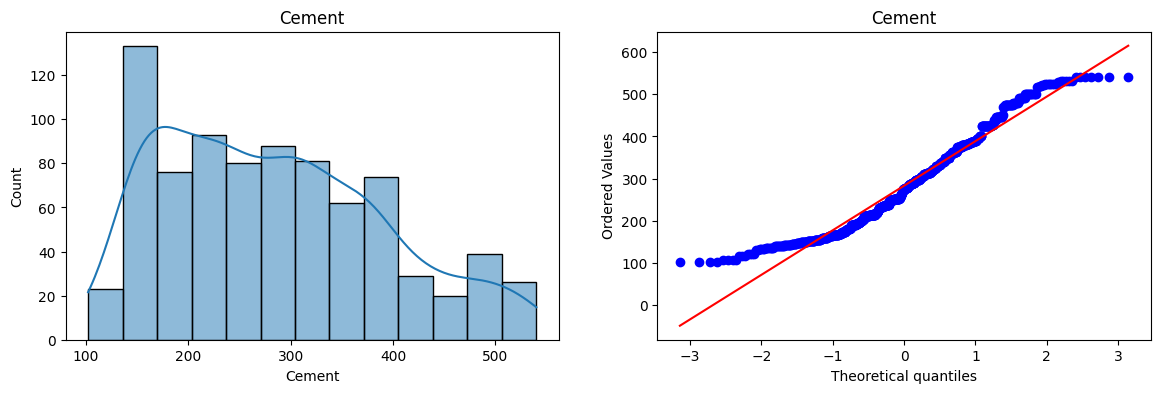

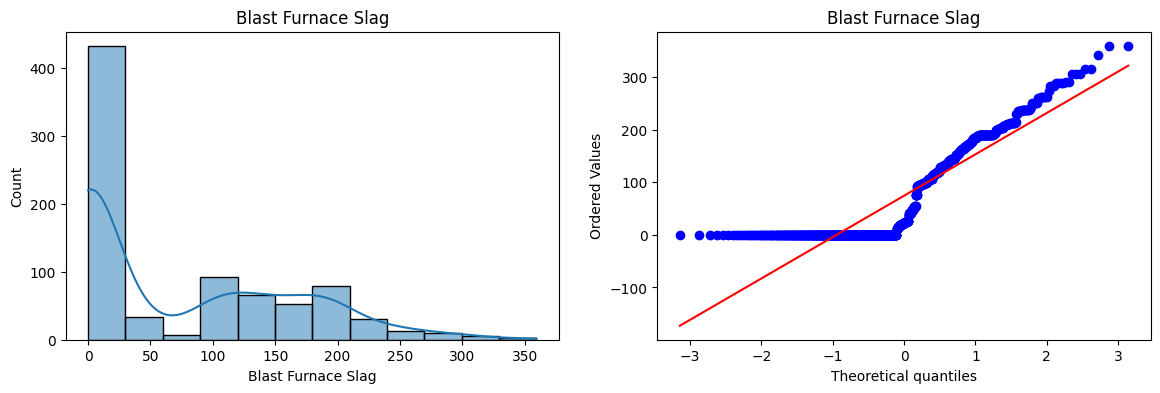

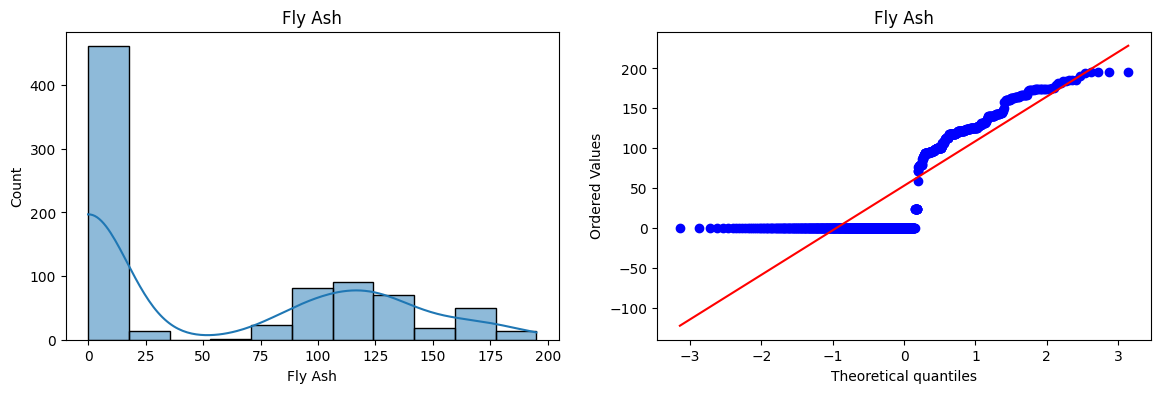

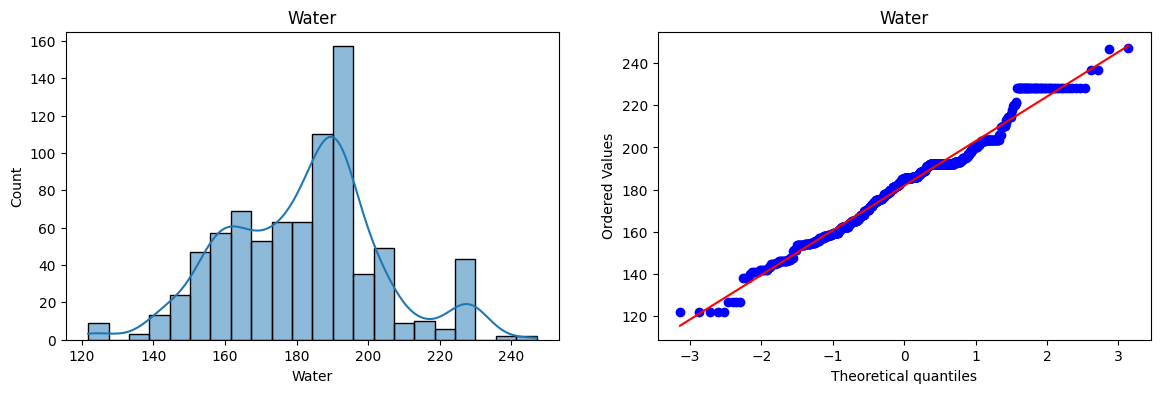

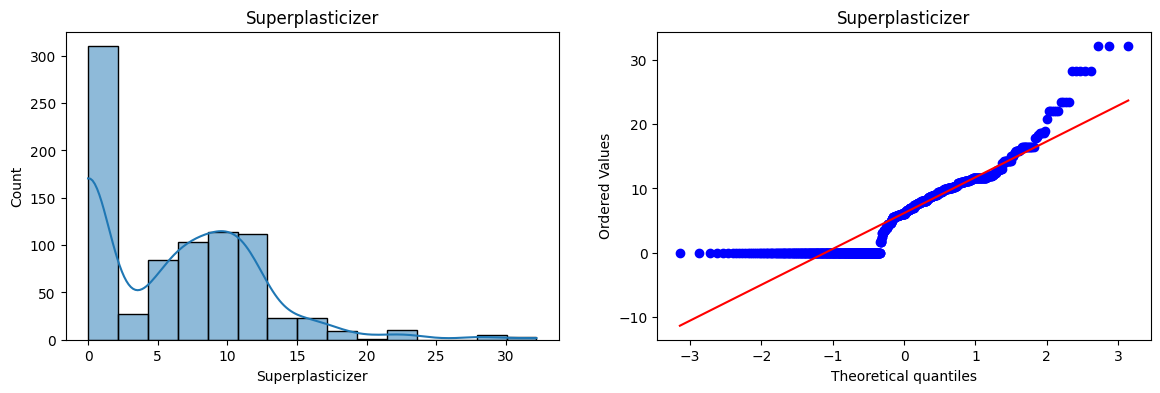

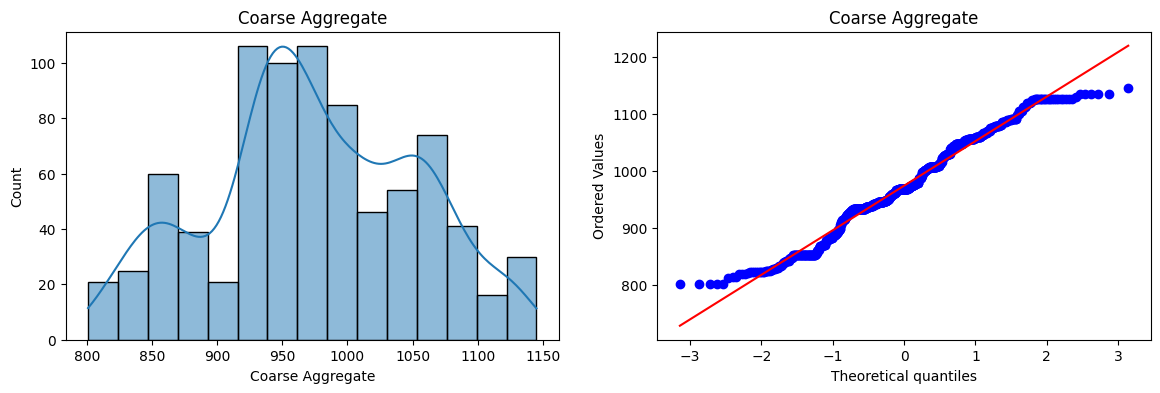

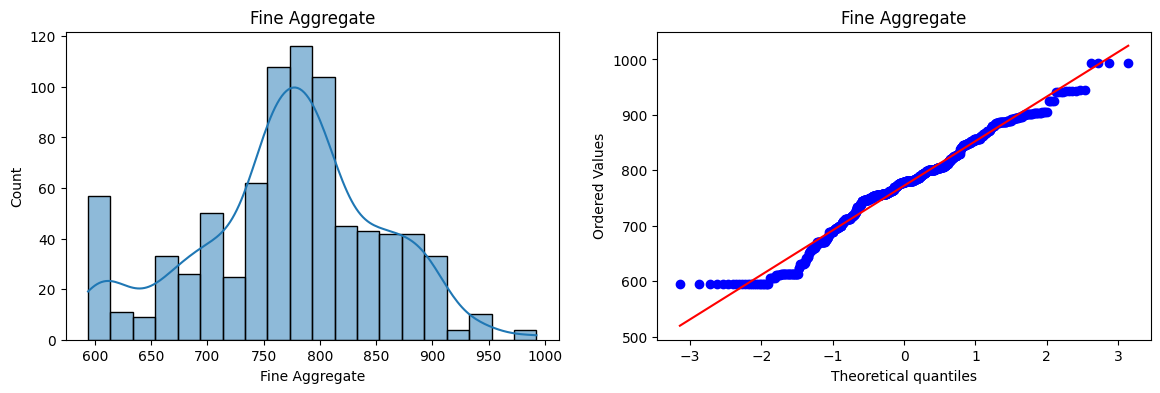

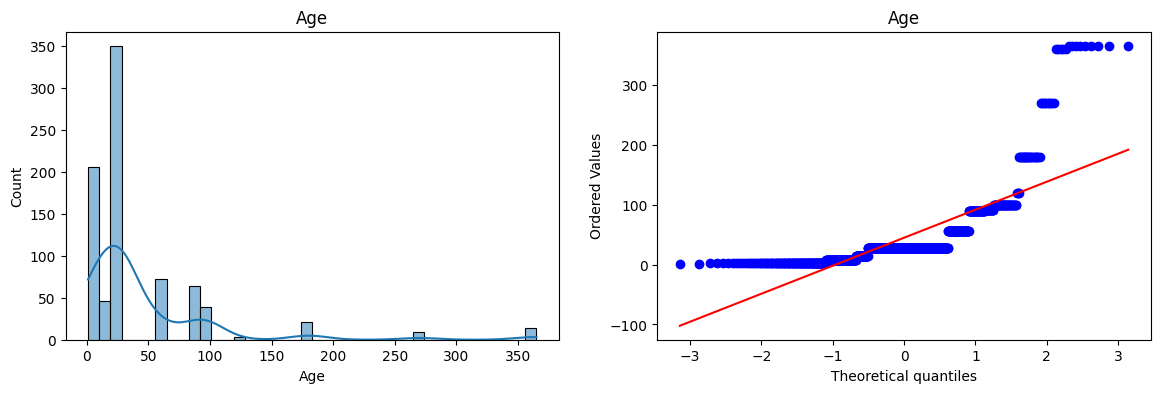

In [29]:
for col in X_train.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(X_train[col],kde=True)
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train[col],dist='norm',plot=plt)
  plt.title(col)

  plt.show()

### **Applying Box Cox Transformation**


In [37]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='box-cox')
X_train_transformed=pt.fit_transform(X_train+0.000001)
X_test_transformed=pt.transform(X_test+0.000001)
pd.DataFrame({'cols':X_train.columns,'box cox_lambdas':pt.lambdas_})

,cols,box cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


Checking r2 score again

In [38]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(X_train_transformed,Y_train)
y_pred2=lr.predict(X_test_transformed)
r2_score(Y_test,y_pred2)

0.8047824993092503

In [41]:
# Using cross val score
pt=PowerTransformer(method='box-cox')
X_transformed=pt.fit_transform(X+0.000001)
lr=LinearRegression()
print(np.mean(cross_val_score(lr,X_transformed,Y,scoring='r2')))

0.6662950329054064


  Before and After Comparison of Box-Cox Plot

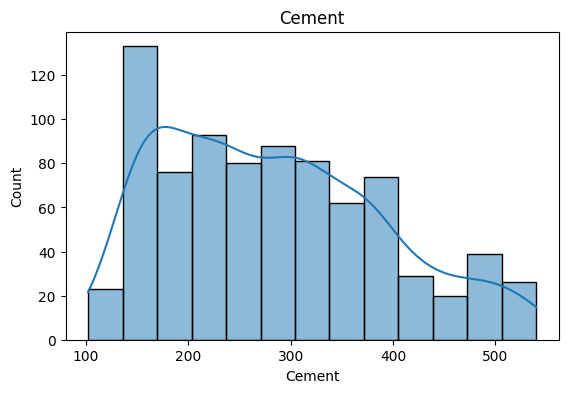

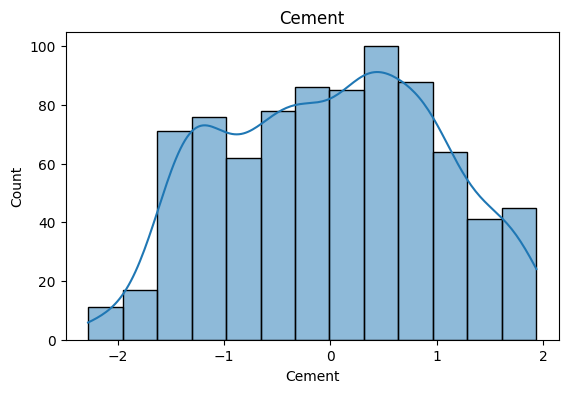

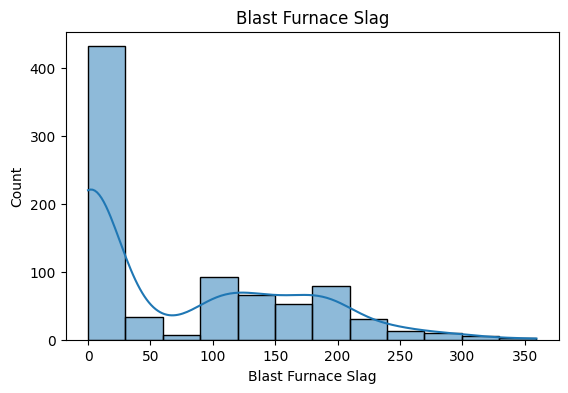

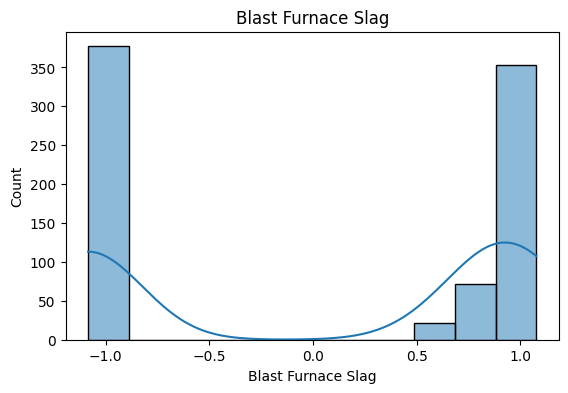

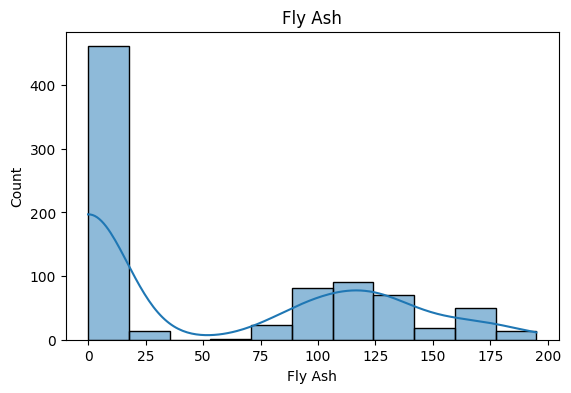

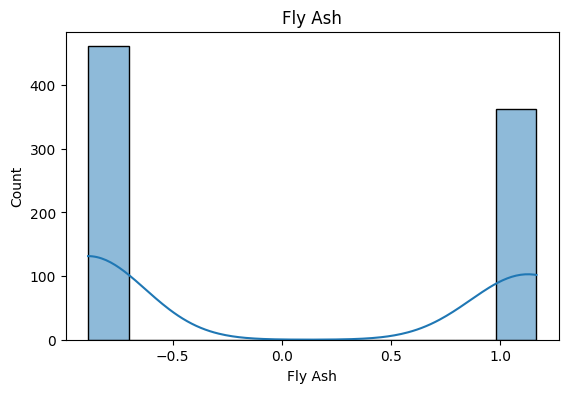

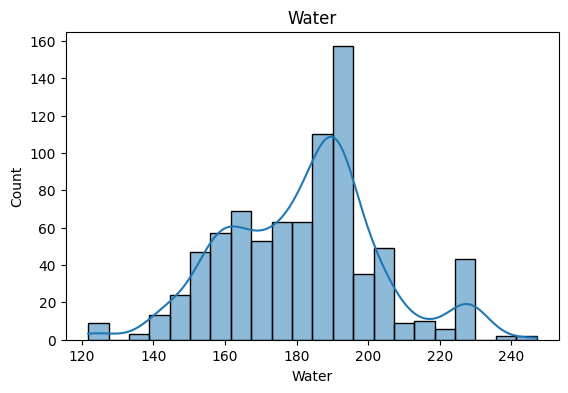

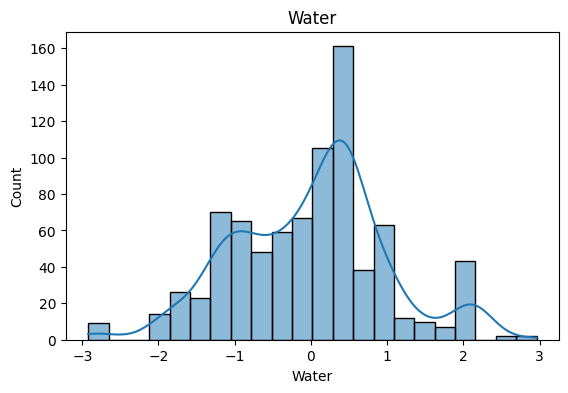

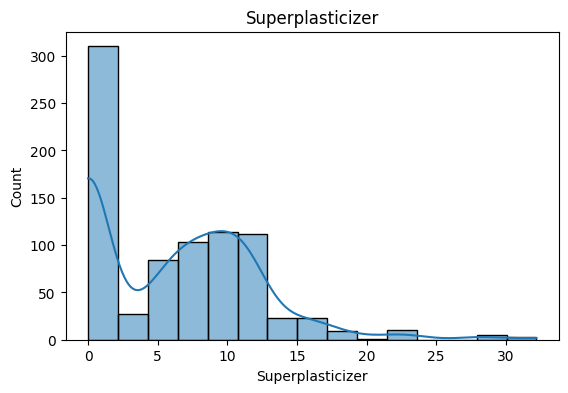

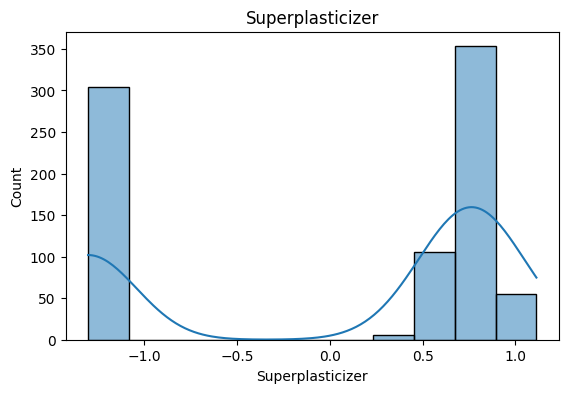

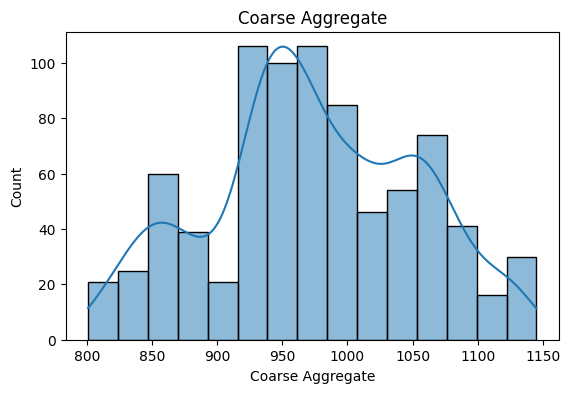

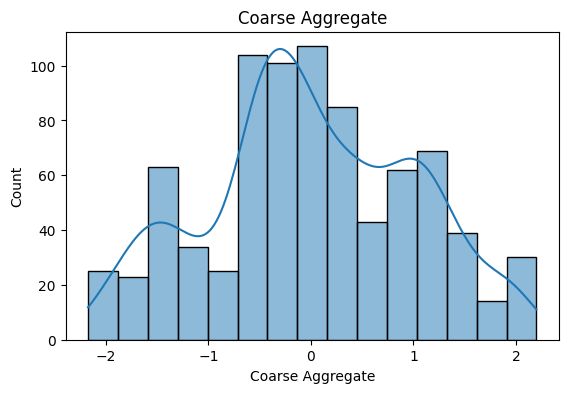

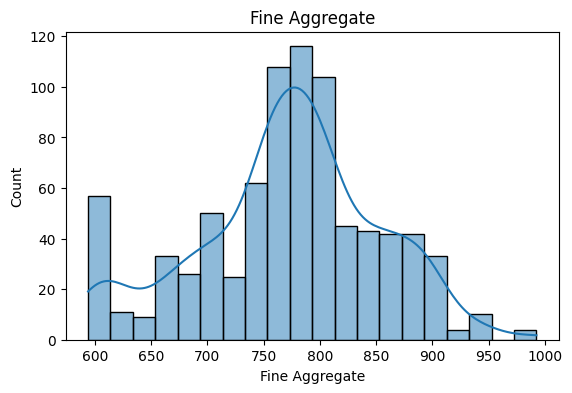

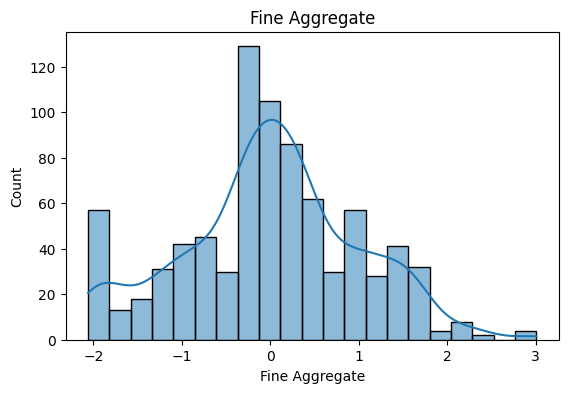

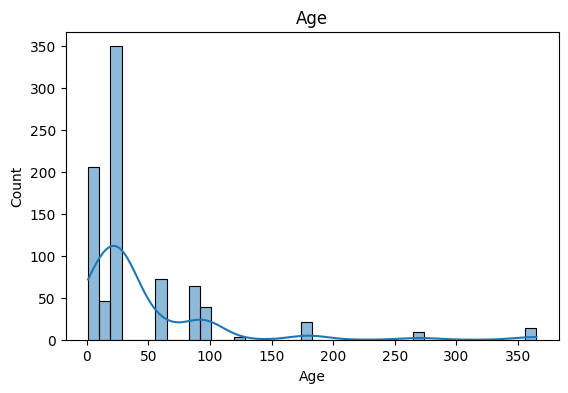

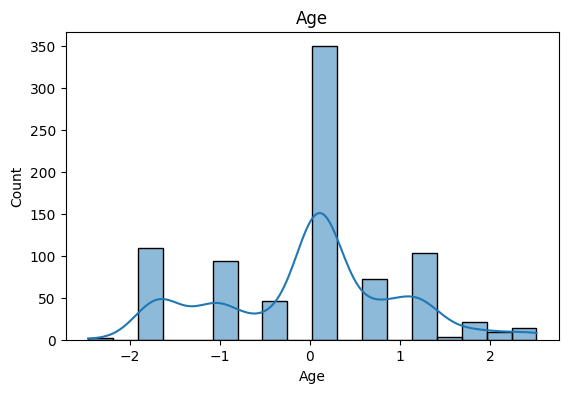

In [48]:
# Converting numpy array to dataframe
X_train_transformed=pd.DataFrame(X_train_transformed,columns=X_train.columns)
for col in X_train_transformed.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(X_train[col],kde=True)
  plt.title(col)

  plt.figure(figsize=(14,4))
  plt.subplot(122)
  sns.histplot(X_train_transformed[col],kde=True)
  plt.title(col)

  plt.show()



Apply Yeo-Johnson Transform

In [49]:
pt1=PowerTransformer()

X_train_transformed2=pt1.fit_transform(X_train)
X_test_transformed2=pt1.transform(X_test)

lr=LinearRegression()
lr.fit(X_train_transformed2,Y_train)
y_pred3=lr.predict(X_test_transformed2)

print(r2_score(Y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,"Yeo Johnson_lambdas":pt1.lambdas_})

0.8161906512004999


,cols,Yeo Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [51]:
# Applying cross val score
pt=PowerTransformer()
X_transformed2=pt.fit_transform(X)

lr=LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,Y,scoring='r2'))


np.float64(0.6834625141500866)

In [52]:
X_train_transformed2=pd.DataFrame(X_train_transformed2,columns=X_train.columns)

Before and After Comparison of Yeo-Johnson

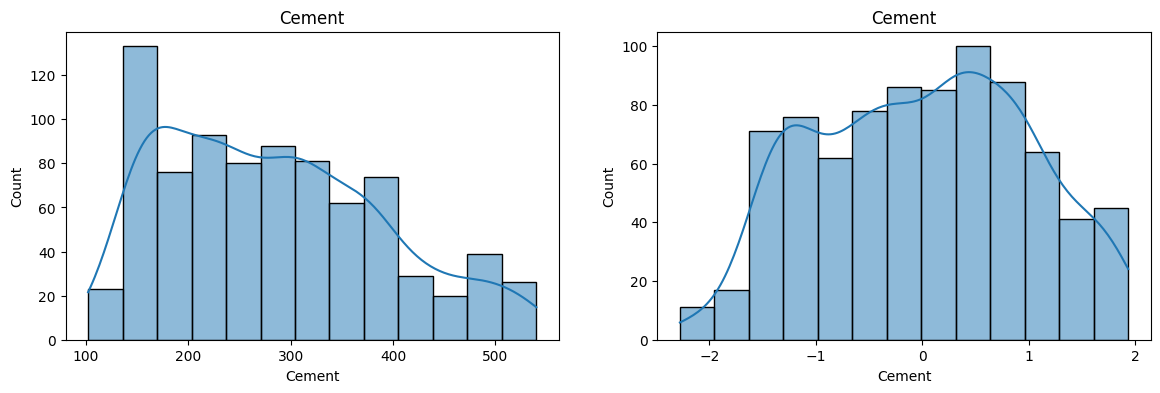

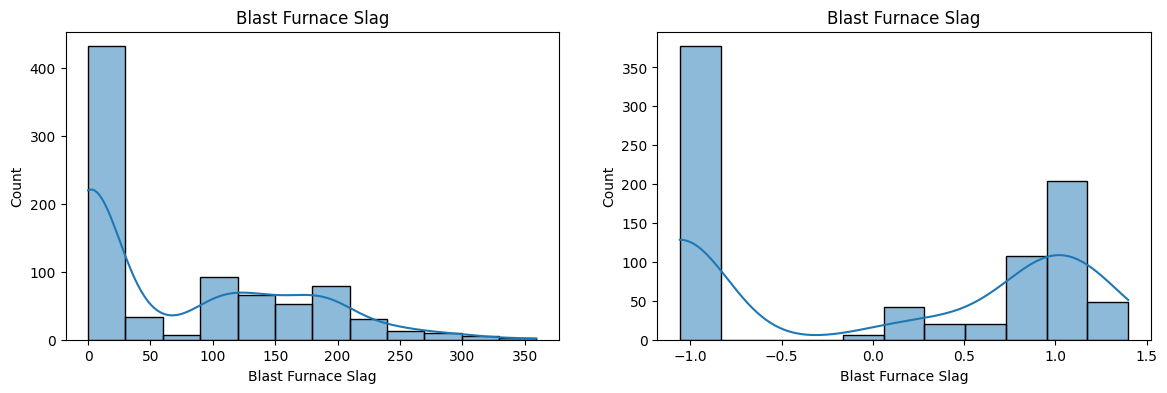

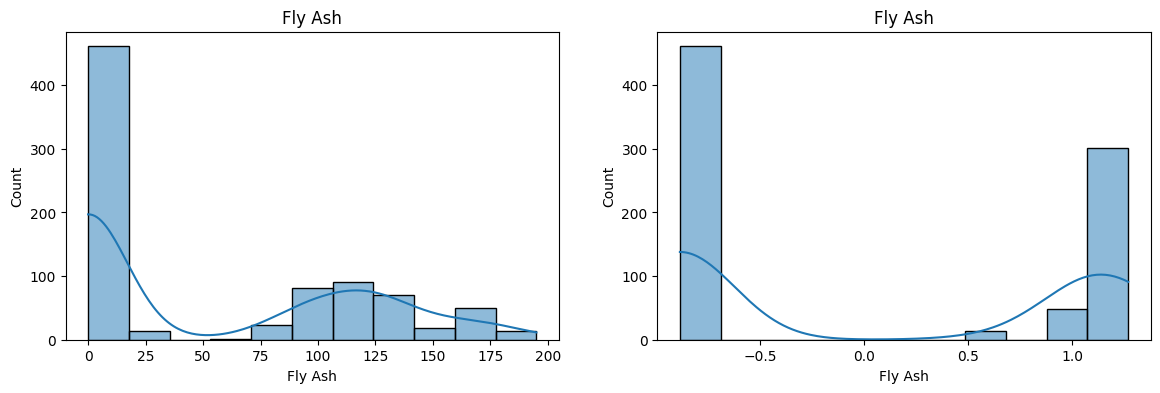

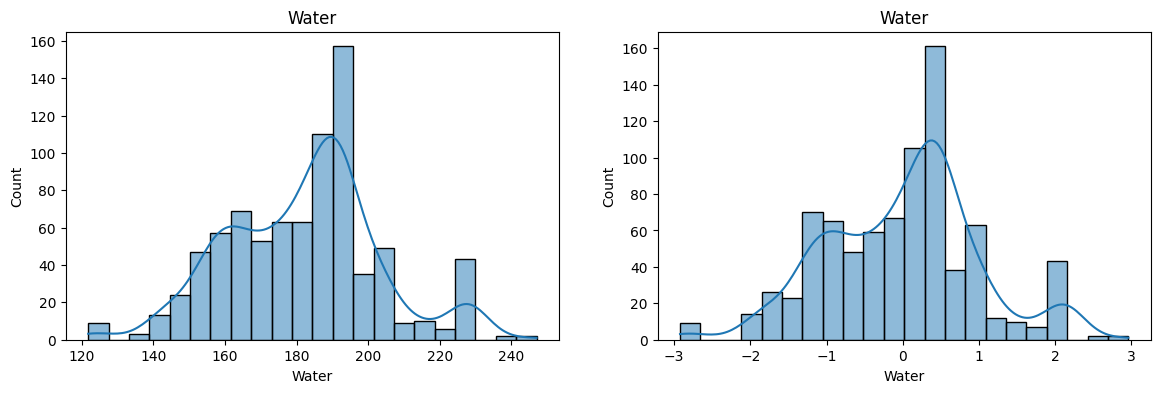

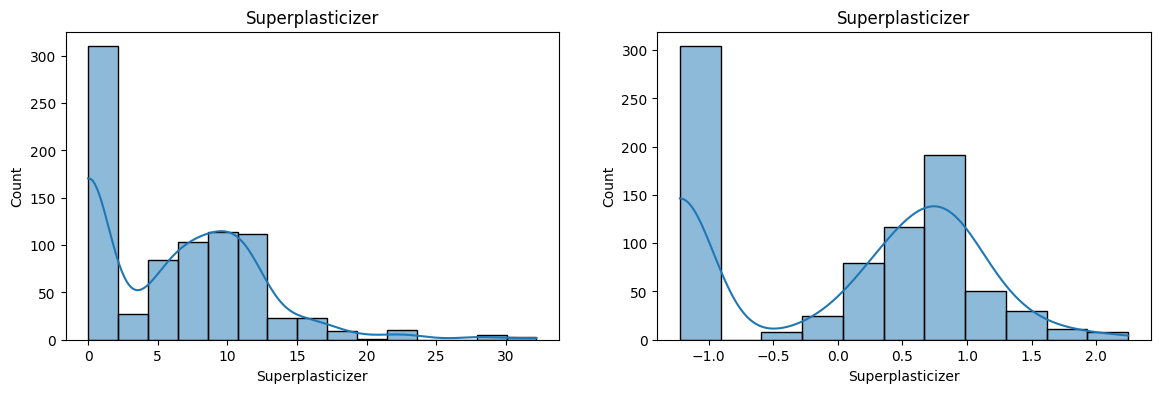

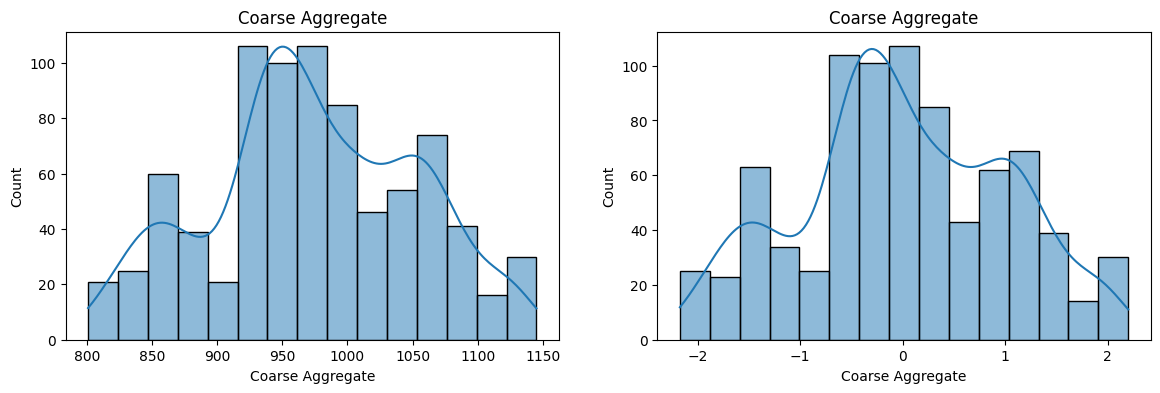

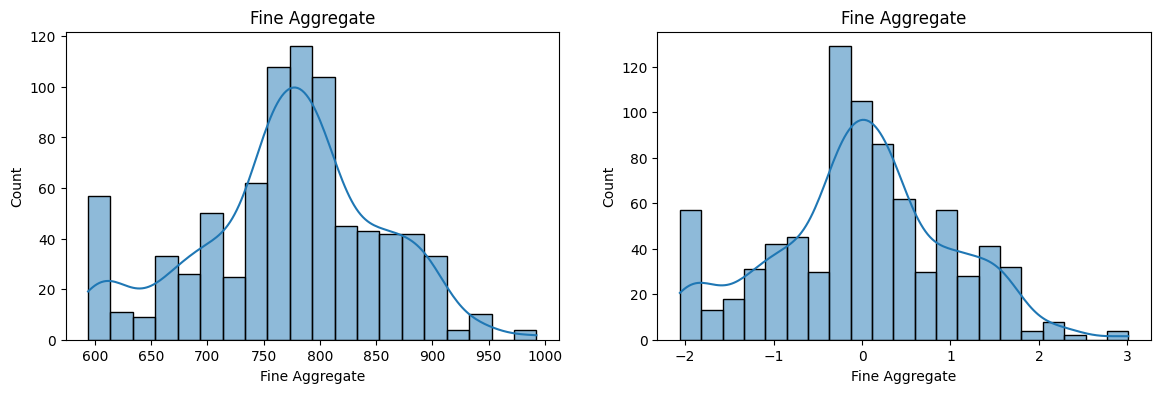

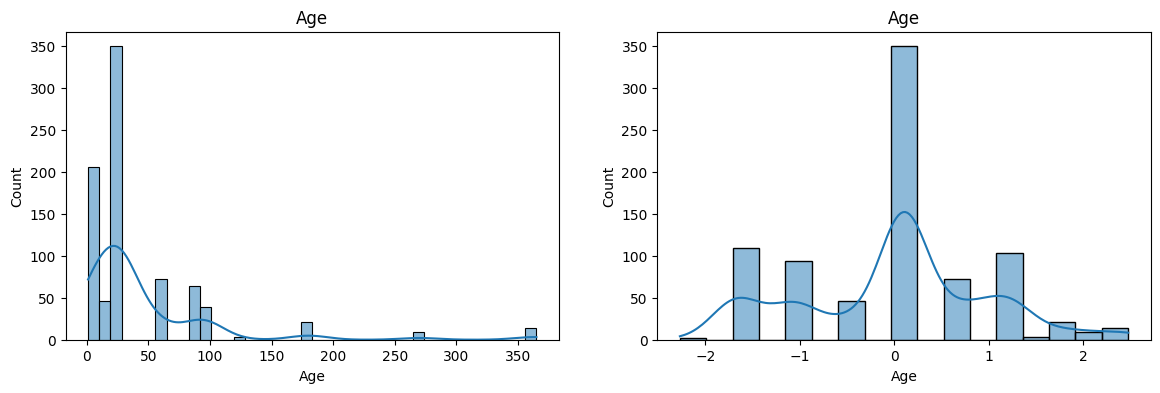

In [53]:
for col in X_train_transformed2.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(X_train[col],kde=True)
  plt.title(col)

  plt.subplot(122)
  sns.histplot(X_train_transformed2[col],kde=True)
  plt.title(col)

  plt.show()

In [54]:
pd.DataFrame({'cols':X_train.columns,'box cox lambdas':pt.lambdas_,'Yeo Johnson Lambdas':pt1.lambdas_})

,cols,box cox lambdas,Yeo Johnson Lambdas
0,Cement,0.169544,0.174348
1,Blast Furnace Slag,0.016633,0.015715
2,Fly Ash,-0.136480,-0.161447
3,Water,0.808438,0.771307
4,Superplasticizer,0.264160,0.253935
5,Coarse Aggregate,1.129395,1.130050
6,Fine Aggregate,1.830763,1.783100
7,Age,0.001771,0.019885
